# Phase 1 — EDA Checkpoint
Validating dataset quality before moving to Phase 2 (detection layers).


In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
with open("../data/processed/malicious_normalized.json", "r", encoding="utf-8") as f:
    mal_data = json.load(f)

with open("../data/processed/benign_normalized.json", "r", encoding="utf-8") as f:
    ben_data = json.load(f)

# Convert lists of dicts → pandas DataFrames
df_mal = pd.DataFrame(mal_data)
df_ben = pd.DataFrame(ben_data)

# Combine into one DataFrame with all records
df_all = pd.concat([df_mal, df_ben], ignore_index=True)

print(f"Malicious: {len(df_mal)} records")
print(f"Benign:    {len(df_ben)} records")
print(f"Total:     {len(df_all)} records")

Malicious: 5 records
Benign:    40 records
Total:     45 records


## 1. Label Distribution
How many malicious vs benign records do we have?

label
benign       40
malicious     5
Name: count, dtype: int64

Ratio (benign:malicious): 40:5


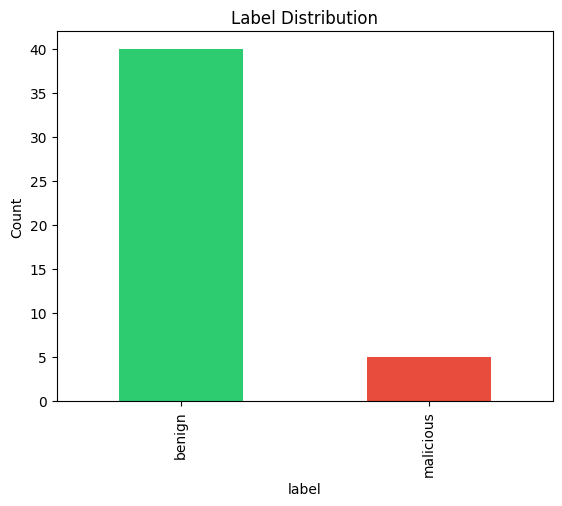

In [4]:
label_counts = df_all["label"].value_counts()

print(label_counts)
print(f"\nRatio (benign:malicious): {label_counts.get('benign', 0)}:{label_counts.get('malicious', 0)}")

# Plot a bar chart
label_counts.plot(kind="bar", color=["#2ecc71", "#e74c3c"])
plt.title("Label Distribution")
plt.ylabel("Count")
plt.show()


## 2. Registry Distribution
How are records distributed across PyPI and npm?


registry   npm  pypi
label               
benign      20    20
malicious    2     3


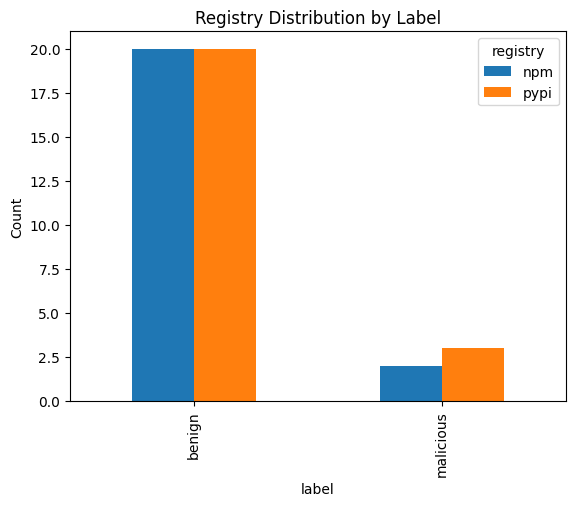

In [5]:
# Cross-tabulate: label × registry
cross_tab = pd.crosstab(df_all["label"], df_all["registry"])
print(cross_tab)

# Plot grouped bar chart
cross_tab.plot(kind="bar")
plt.title("Registry Distribution by Label")
plt.ylabel("Count")
plt.show()


## 3. Missing Field Rates
Which fields have missing (null/None) values?


In [6]:
# Calculate missing rate for each column
missing = df_all.isnull().sum()
missing_pct = (missing / len(df_all) * 100).round(2)

missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report = missing_report.sort_values(by="missing_count", ascending=False)
print(missing_report)


              missing_count  missing_pct
package_name              0          0.0
registry                  0          0.0
label                     0          0.0
version                   0          0.0
source_url                0          0.0
collected_at              0          0.0


## 4. Sample Records
Quick look at the actual data:


In [7]:
print("=== Malicious samples ===")
df_mal.head(3)


print("=== Benign samples ===")
df_ben.head(3)


=== Malicious samples ===
=== Benign samples ===


,package_name,registry,label,version,source_url,collected_at
0,axios,npm,benign,,,2026-02-24T20:41:40.282240
1,black,pypi,benign,,,2026-02-24T20:41:40.282240
2,boto3,pypi,benign,,,2026-02-24T20:41:40.282240
